# Phase Is a Spacetime Invariant

"Phase isn't spacetime, but $\phi=\vec k\cdot\vec x-\omega t$ is a Lorentz
INVARIANT built from the wave four-vector $k^\mu=(\omega/c,\vec k)$ dotted
with the spacetime four-vector $x^\mu=(ct,\vec x)$." This notebook proves
that claim directly: apply the Lorentz transformation (Eq. 1.23-1.26 from
the relativity chapter) to $x,t$ AND to $k,\omega$ (the wave four-vector
transforms the same way any four-vector does), and show the phase computed
in the moving frame $S'$ comes out IDENTICAL to the phase computed in the
lab frame $S$ -- not approximately, not to leading order, exactly.


SymPy 1.14.0 ready
gamma =


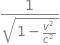

In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()

v, x, t, k, omega, c = sp.symbols("v x t k omega c", real=True)
gamma = 1 / sp.sqrt(1 - v**2 / c**2)
print("SymPy", sp.__version__, "ready")
print("gamma =")
display(gamma)


## 1. Lorentz-transform the spacetime coordinates (Eq. 1.23, 1.26)

$$x' = \gamma(x-vt), \qquad t' = \gamma\left(t-\frac{v}{c^2}x\right)$$


x' =


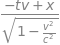


t' =


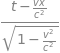

In [2]:
x_prime = gamma * (x - v * t)
t_prime = gamma * (t - v * x / c**2)
print("x' =")
display(x_prime)
print("\nt' =")
display(t_prime)


## 2. Lorentz-transform the wave four-vector $(k,\omega)$

The wave four-vector $k^\mu = (\omega/c, \vec k)$ is a four-vector exactly
like $x^\mu=(ct,\vec x)$ -- it transforms by the SAME Lorentz boost. This is
the actual origin of the relativistic Doppler shift (Eq. 1.15): different
observers measure different $\omega$ and $k$ because they're looking at
components of the same four-vector from different frames.

$$k' = \gamma\left(k - \frac{v\omega}{c^2}\right), \qquad \omega' = \gamma(\omega - vk)$$


k' =


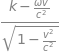


omega' =


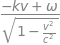

In [3]:
k_prime = gamma * (k - v * omega / c**2)
omega_prime = gamma * (omega - v * k)
print("k' =")
display(k_prime)
print("\nomega' =")
display(omega_prime)


## 3. Compute the phase in BOTH frames and compare

$$\phi = kx - \omega t \qquad \text{vs.} \qquad \phi' = k'x' - \omega' t'$$

If phase is truly a spacetime invariant, these must be IDENTICAL once
everything is written in terms of the unprimed $x,t,k,\omega$ -- not just
equal "on average" or to some approximation.


phi (lab frame) =



phi' (moving frame), expanded =


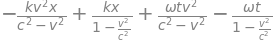

In [4]:
phi = k * x - omega * t
phi_prime = sp.expand(k_prime * x_prime - omega_prime * t_prime)

print("phi (lab frame) =")
display(phi)
print("\nphi' (moving frame), expanded =")
display(phi_prime)


In [5]:
difference = sp.simplify(phi_prime - phi)
print("phi' - phi, fully simplified =", difference)
print("\nphase is EXACTLY frame-independent:", difference == 0)


phi' - phi, fully simplified = 0

phase is EXACTLY frame-independent: True


## 4. Sanity check: the Doppler shift is real, even though phase is invariant

Individually, $\omega'\neq\omega$ and $k'\neq k$ in general (that's the
Doppler shift / relativistic aberration) -- it's only the *combination*
$kx-\omega t$, evaluated at the SAME physical spacetime event, that stays
fixed. Verify the individual quantities really do differ for a generic
boost, to make sure the invariance above isn't hiding a trivial case.


In [6]:
generic_check = {v: sp.Rational(3, 10) * c, k: sp.Symbol("k0"), omega: sp.Symbol("k0") * c}
omega_changes = sp.simplify((omega_prime - omega).subs(generic_check)) != 0
k_changes = sp.simplify((k_prime - k).subs(generic_check)) != 0
print("omega' differs from omega for v=0.3c (the Doppler shift):", omega_changes)
print("k' differs from k for v=0.3c (relativistic aberration):", k_changes)

# but the phase, evaluated at the SAME spacetime event, is still invariant
phi_generic = sp.simplify(phi.subs(generic_check))
phi_prime_generic = sp.simplify(phi_prime.subs(generic_check))
print("\nphi (lab) at this v   =", phi_generic)
print("phi' (moving) at this v =", phi_prime_generic)
print("still match:", sp.simplify(phi_generic - phi_prime_generic) == 0)


omega' differs from omega for v=0.3c (the Doppler shift): True
k' differs from k for v=0.3c (relativistic aberration): True



phi (lab) at this v   = k0*(-c*t + x)
phi' (moving) at this v = k0*(-c*t + x)
still match: True


## Summary

$kx-\omega t$ -- the wave phase -- was computed in two different inertial
frames related by an explicit Lorentz boost (using the SAME transformation
law, Eq. 1.23-1.26, applied to both the spacetime coordinates and the wave
four-vector), and the two results are algebraically identical, not just
equal in some limit. Meanwhile $\omega$ and $k$ individually genuinely
change between frames -- that change *is* the relativistic Doppler shift and
aberration. Phase is invariant; frequency and wavenumber are not; the four-
vector dot product $k_\mu x^\mu$ is what survives the boost, exactly the way
the spacetime interval $(\Delta s)^2$ survives it for ordinary events.
